注意力汇聚本质上就是对输入做加权平均
其中权重又给定的 query 和不同的 key 之间计算得到

In [9]:
import matplotlib.pyplot as plt

def show_heatmaps(matrices, xlabel='Query', ylabel='Key', titles=None, figsize=(2.5, 2.5), cmap='Reds'):
    """
    可视化注意力权重热力图，直观体现：每一个查询，分别给每一个键分配了多大的关注度
    Args:
        matrices: 4维张量 [画布行数, 画布列数, num_queries, num_keys]
        titles: 子图标题列表
        figsize: 单张子图尺寸
        cmap: 热力配色
    """
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(
        num_rows, num_cols,
        figsize=(figsize[0]*num_cols, figsize[1]*num_rows),
        sharex=True, sharey=True,
        squeeze=False
    )

    pcm = None
    for i, (row_axes, row_mats) in enumerate(zip(axes, matrices)):
        for j, (ax, mat) in enumerate(zip(row_axes, row_mats)):
            data = mat.detach().cpu().numpy()
            pcm = ax.imshow(data, cmap=cmap)
            # 仅底行显示x标签
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            # 仅首列显示y标签
            if j == 0:
                ax.set_ylabel(ylabel)
            # 设置子图标题
            if titles is not None:
                ax.set_title(titles[j])
    # 全局色条
    fig.colorbar(pcm, shrink=0.6)
    plt.tight_layout()
    plt.show()

In [17]:
import matplotlib.pyplot as plt
import torch

def plot_kernel_reg(
    x_test: torch.Tensor,
    y_truth: torch.Tensor,
    y_hat: torch.Tensor,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
):
    """
    可视化核回归拟合结果
    Args:
        x_test: 测试集x坐标
        y_truth: 真实函数值
        y_hat: 核回归预测值
        x_train: 训练样本x
        y_train: 训练样本y
    """
    # 切换矢量高清渲染
    plt.rcParams['figure.dpi'] = 150
    plt.figure(figsize=(5, 3))

    # 绘制真实曲线 & 预测拟合曲线
    plt.plot(x_test.cpu().numpy(), y_truth.cpu().numpy(), label="Truth", linewidth=1.2)
    plt.plot(x_test.cpu().numpy(), y_hat.cpu().numpy(), label="Pred", linewidth=1.2)

    # 绘制训练离散样本圆点，半透明
    plt.scatter(
        x_train.cpu().numpy(),
        y_train.cpu().numpy(),
        marker='o',
        alpha=0.5,
        s=18
    )

    # 坐标轴、图例、边界
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(fontsize=8)
    plt.tight_layout()  # 紧凑布局，避免标签截断
    plt.show()

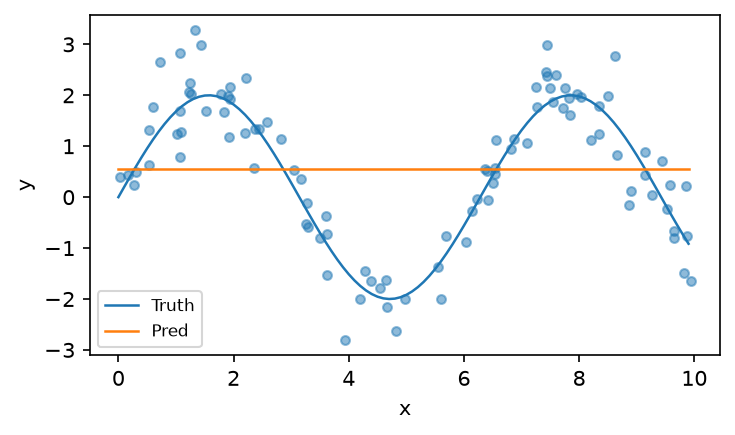

In [18]:
import torch
from torch import nn

n_train = 100
x_train, _ = torch.sort(torch.rand(n_train) * 10)
y_train = 2 * torch.sin(x_train) + torch.normal(0.0, 0.5, (n_train,))

x_test = torch.arange(0, 10, 0.1)
y_truth = 2 * torch.sin(x_test)
n_test = len(x_test)

y_hat = torch.repeat_interleave(y_tarin.mean(), n_test)
plot_kernel_reg(x_test, y_truth, y_hat, x_train, y_train)

核回归：用邻近样本加权平均预测新点，即用距离算相似度权重，近处样本权重高

$$
\hat{y}(x) = \frac{\sum_{i=1}^{n} K(x, x_i)\, y_i}{\sum_{i=1}^{n} K(x, x_i)}
$$
常用的核为高斯核 $K(u) = \frac{1}{\sqrt{2 \pi}}\exp(- \frac{u^2}{2})$

核回归是惰性局部模型，预测逻辑只依赖周边训练样本，所以在远离训练样本的空白区域预测效果极差

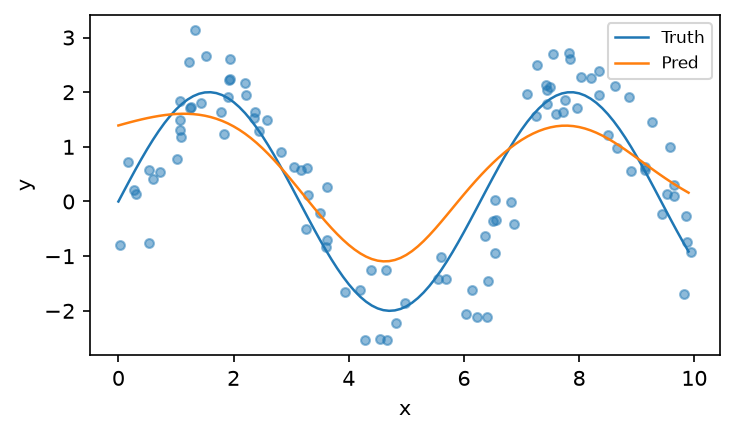

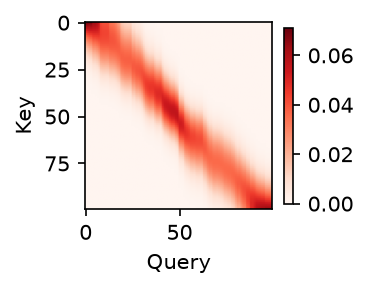

In [19]:
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
y_hat = torch.matmul(attention_weights, y_train)

plot_kernel_reg(x_test, y_truth, y_hat, x_train, y_tarin)

show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0))

上述的核回归为非参数模型，仅靠输入数据本身做加权预测
只有当数据足够多时，模型才能收敛到最优结果

一种简单的改进方式是往核函数中加入可学习参数 w
$K(x - x_i) = \frac{1}{\sqrt{2 \pi}} \exp(-\frac{1}{2}((x - x_i)w)^2)$

In [11]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # 可学习参数：高斯核带宽 w
        self.w = nn.Parameter(torch.rand((1,)), requires_grad=True)

    def forward(self, queries, keys, values):
        # queries, keys, values 形状：[查询总数, 键值对数量]
        
        # 复制扩展查询
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
    
        # 注意力权重
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1
        )
    
        # 加权求和values，压平维度输出预测
        return torch.bmm(
            self.attention_weights.unsqueeze(1),
            values.unsqueeze(-1)
        ).reshape(-1)

In [20]:
"Train Model"

X_tile = x_train.repeat((n_train, 1))  # shape (n_train, n_train)
Y_tile = y_train.repeat((n_train, 1))  # shape (n_train, n_train)

mask = (1 - torch.eye(n_train)).type(torch.bool)

keys = X_tile[mask].reshape((n_train, -1))     # shape (n_train, n_train-1)
values = Y_tile[mask].reshape((n_train, -1))   # shape (n_train, n_train-1)

net = NWKernelRegression()
loss = nn.MSELoss(reduction='none') # reduction='none'：不自动求和，输出每个样本单独损失
trainer = torch.optim.SGD(net.parameters(), lr=0.5)

num_epochs = 10
for epoch in range(num_epochs):
    trainer.zero_grad()  # 清空上一轮梯度缓存

    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()   # 全部样本损失求和
    trainer.step()       # SGD更新参数w

    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')

epoch 1, loss 112.457016
epoch 2, loss 48.675076
epoch 3, loss 48.674713
epoch 4, loss 48.674362
epoch 5, loss 48.674007
epoch 6, loss 48.673645
epoch 7, loss 48.673286
epoch 8, loss 48.672928
epoch 9, loss 48.672569
epoch 10, loss 48.672215


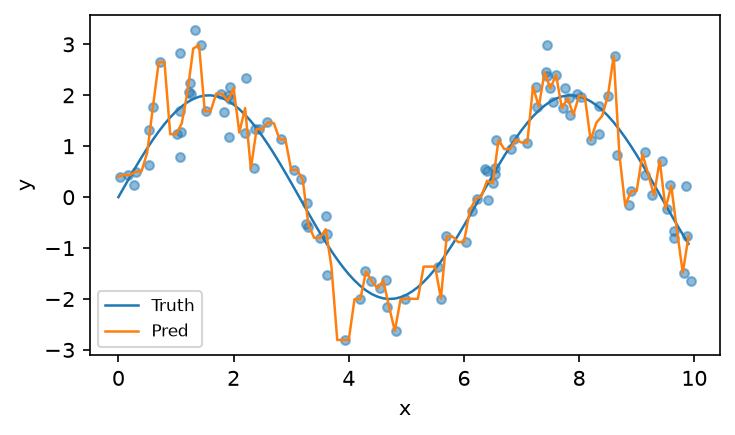

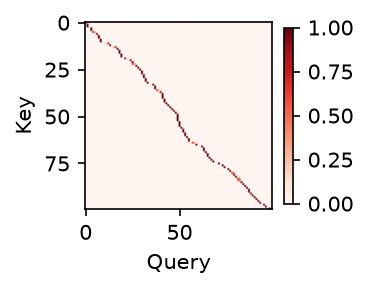

In [21]:
"Test Model"

keys = x_train.repeat((n_test, 1))    # shape (n_test, n_train)
values = y_train.repeat((n_test, 1))   # shape (n_test, n_train)

y_hat = net(x_test, keys, values).unsqueeze(1).detach()

plot_kernel_reg(x_test, y_truth, y_hat, x_train, y_train)
show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0))